# Which plan performs better?

This project analyzes customer behavior and revenue for two prepaid plans offered by Megaline: Surf and Ultimate. The goal is to understand how customers use each plan and determine which one generates more revenue on average. Using data for 500 customers, the analysis examines call activity, text message usage, internet consumption, and monthly revenue patterns.

The work includes data cleaning, exploratory analysis, and hypothesis testing to provide a data-driven recommendation for the marketing team. The results are intended to support better decisions about advertising spend and plan positioning.

## Initialization

In [7]:
# Import all libraries
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from scipy import stats as st

## Load the data

In [8]:
# Load the data files into separate DataFrames
calls_df = pd.read_csv('D:/DevTools/TripleTen_Data Science/Sprint 5/megaline_calls.csv')
internet_df = pd.read_csv('D:/DevTools/TripleTen_Data Science/Sprint 5/megaline_internet.csv')
messages_df = pd.read_csv('D:/DevTools/TripleTen_Data Science/Sprint 5/megaline_messages.csv')
plans_df = pd.read_csv('D:/DevTools/TripleTen_Data Science/Sprint 5/megaline_plans.csv')
users_df = pd.read_csv('D:/DevTools/TripleTen_Data Science/Sprint 5/megaline_users.csv')

## Prepare the data

## Plans

In [9]:
# Imprime la información general/resumida sobre el DataFrame de las tarifas
plans_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      str    
dtypes: float64(2), int64(5), str(1)
memory usage: 260.0 bytes


In [10]:
# Imprime una muestra de los datos para las tarifas
print(plans_df)

   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0               20          10             0.03            0.03      surf  
1               70           7             0.01            0.01  ultimate  


## Clean the data

In [11]:
plans_df['mb_per_month_included'] = plans_df['mb_per_month_included'] / 1014  # convert MB to GB
print(plans_df['mb_per_month_included'][0])
print(plans_df['mb_per_month_included'][1])

15.14792899408284
30.29585798816568


## Enrich the data

## Users

In [12]:
# Imprime la información general/resumida sobre el DataFrame de usuarios
users_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   user_id     500 non-null    int64
 1   first_name  500 non-null    str  
 2   last_name   500 non-null    str  
 3   age         500 non-null    int64
 4   city        500 non-null    str  
 5   reg_date    500 non-null    str  
 6   plan        500 non-null    str  
 7   churn_date  34 non-null     str  
dtypes: int64(2), str(6)
memory usage: 31.4 KB


In [13]:
# Imprime una muestra de datos para usuarios
print(users_df.head(10))

   user_id first_name  last_name  age                                    city  \
0     1000   Anamaria      Bauer   45   Atlanta-Sandy Springs-Roswell, GA MSA   
1     1001     Mickey  Wilkerson   28         Seattle-Tacoma-Bellevue, WA MSA   
2     1002     Carlee    Hoffman   36    Las Vegas-Henderson-Paradise, NV MSA   
3     1003   Reynaldo    Jenkins   52                           Tulsa, OK MSA   
4     1004    Leonila   Thompson   40         Seattle-Tacoma-Bellevue, WA MSA   
5     1005      Livia    Shields   31     Dallas-Fort Worth-Arlington, TX MSA   
6     1006     Jesusa   Bradford   73  San Francisco-Oakland-Berkeley, CA MSA   
7     1007    Eusebio      Welch   42           Grand Rapids-Kentwood, MI MSA   
8     1008      Emely    Hoffman   53       Orlando-Kissimmee-Sanford, FL MSA   
9     1009      Gerry     Little   19  San Jose-Sunnyvale-Santa Clara, CA MSA   

     reg_date      plan  churn_date  
0  2018-12-24  ultimate         NaN  
1  2018-08-13      surf         

The data types for the date columns are currently stored as objects, but they should be converted to datetime. The city names in the 'city' column contain hyphens, which can be normalized for consistency. There are also missing values in the 'churn_date' column, which is expected because some customers were still active at the time the dataset was extracted.

### Clean the data

In [14]:
# Convert date columns from object to datetime format
users_df['reg_date'] = pd.to_datetime(users_df['reg_date'], format='%Y-%m-%d')
users_df['churn_date'] = pd.to_datetime(users_df['churn_date'], format='%Y-%m-%d')
print(f"users_df['reg_date']: {users_df['reg_date'].dtype}")
print(f"users_df['churn_date']: {users_df['churn_date'].dtype}")

users_df['reg_date']: datetime64[us]
users_df['churn_date']: datetime64[us]


### Enrich the data

In [15]:
# Replace hyphens with spaces in city names
users_df['city'] = users_df['city'].str.replace('-', ' ')
users_df['city'].head(10)
print()
# Check for missing or duplicated values
print('Number of duplicate values:', users_df.duplicated().sum())
print('Number of missing values:', users_df.isna().sum())


Number of duplicate values: 0
Number of missing values: user_id         0
first_name      0
last_name       0
age             0
city            0
reg_date        0
plan            0
churn_date    466
dtype: int64


## Calls

In [16]:
# Imprime la información general/resumida sobre el DataFrame de las llamadas
calls_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  str    
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  str    
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), str(2)
memory usage: 4.2 MB


In [17]:
# Imprime una muestra de datos para las llamadas
print(calls_df.head(20))

          id  user_id   call_date  duration
0    1000_93     1000  2018-12-27      8.52
1   1000_145     1000  2018-12-27     13.66
2   1000_247     1000  2018-12-27     14.48
3   1000_309     1000  2018-12-28      5.76
4   1000_380     1000  2018-12-30      4.22
5   1000_388     1000  2018-12-31      2.20
6   1000_510     1000  2018-12-27      5.75
7   1000_521     1000  2018-12-28     14.18
8   1000_530     1000  2018-12-28      5.77
9   1000_544     1000  2018-12-26      4.40
10  1000_693     1000  2018-12-31      4.31
11  1000_705     1000  2018-12-31     12.78
12  1000_735     1000  2018-12-29      1.70
13  1000_778     1000  2018-12-28      3.29
14  1000_826     1000  2018-12-26      9.96
15  1000_842     1000  2018-12-27      5.85
16    1001_0     1001  2018-09-06     10.06
17    1001_1     1001  2018-10-12      1.00
18    1001_2     1001  2018-10-17     15.83
19    1001_4     1001  2018-12-05      0.00


The 'call_date' column can be converted to datetime format. The values in the 'duration' column also appear unusual and should be reviewed carefully before analysis.

### Clean the data

In [18]:
# Convert the date column from object to datetime format
calls_df['call_date'] = pd.to_datetime(calls_df['call_date'], format='%Y-%m-%d')
print(calls_df['call_date'].dtype)

datetime64[us]


### Enrich the data

In [19]:
# Round call durations up to the nearest whole minute for consistency
calls_df['duration'] = np.ceil(calls_df['duration'])
print(calls_df['duration'].head(15))
# Check for missing or duplicated values
print('Number of duplicate values:', calls_df.duplicated().sum())
print('Number of missing values:', calls_df.isna().sum())

0      9.0
1     14.0
2     15.0
3      6.0
4      5.0
5      3.0
6      6.0
7     15.0
8      6.0
9      5.0
10     5.0
11    13.0
12     2.0
13     4.0
14    10.0
Name: duration, dtype: float64
Number of duplicate values: 0
Number of missing values: id           0
user_id      0
call_date    0
duration     0
dtype: int64


## Mensajes

In [20]:
# Imprime la información general/resumida sobre el DataFrame de los mensajes
messages_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   id            76051 non-null  str  
 1   user_id       76051 non-null  int64
 2   message_date  76051 non-null  str  
dtypes: int64(1), str(2)
memory usage: 1.7 MB


In [21]:
# Imprime una muestra de datos para los mensajes
print(messages_df.head(10))

         id  user_id message_date
0  1000_125     1000   2018-12-27
1  1000_160     1000   2018-12-31
2  1000_223     1000   2018-12-31
3  1000_251     1000   2018-12-27
4  1000_255     1000   2018-12-26
5  1000_346     1000   2018-12-29
6  1000_386     1000   2018-12-30
7  1000_413     1000   2018-12-31
8  1000_502     1000   2018-12-27
9  1000_525     1000   2018-12-28


The 'message_date' column can be converted to datetime format. No duplicate or missing values were found in this dataset.

### Clean the data

In [22]:
# Convert the date column from object to datetime format
messages_df['message_date'] = pd.to_datetime(messages_df['message_date'], format='%Y-%m-%d')
print(messages_df['message_date'].dtype)

datetime64[us]


### Enrich the data

In [23]:
print('Number of duplicate values:', messages_df.duplicated().sum())
print('Number of missing values:', messages_df.isna().sum())

Number of duplicate values: 0
Number of missing values: id              0
user_id         0
message_date    0
dtype: int64


## Internet

In [24]:
# Imprime la información general/resumida sobre el DataFrame de internet
internet_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  str    
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  str    
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), str(2)
memory usage: 3.2 MB


In [25]:
# Imprime una muestra de datos para el tráfico de internet
print(internet_df.head(10))

         id  user_id session_date  mb_used
0   1000_13     1000   2018-12-29    89.86
1  1000_204     1000   2018-12-31     0.00
2  1000_379     1000   2018-12-28   660.40
3  1000_413     1000   2018-12-26   270.99
4  1000_442     1000   2018-12-27   880.22
5    1001_0     1001   2018-08-24   284.68
6    1001_3     1001   2018-12-09   656.04
7    1001_4     1001   2018-11-04    16.97
8   1001_10     1001   2018-11-27   135.18
9   1001_15     1001   2018-12-13   761.92


The 'session_date' column can be converted to datetime format. No duplicate or missing values were found in this dataset.

### Clean the data

In [26]:
# Convert the date column from object to datetime format
internet_df['session_date'] = pd.to_datetime(internet_df['session_date'], format='%Y-%m-%d')
print(internet_df['session_date'].dtype)

datetime64[us]


### Enrich the data

In [27]:
print('Number of duplicate values:', internet_df.duplicated().sum())
print('Number of missing values:', internet_df.isna().sum())

Number of duplicate values: 0
Number of missing values: id              0
user_id         0
session_date    0
mb_used         0
dtype: int64


## Study the plan conditions

In [28]:
# Review the plan conditions to make sure they are clear before proceeding
plans_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      float64
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      str    
dtypes: float64(3), int64(4), str(1)
memory usage: 260.0 bytes


## Aggregate data by user

In [29]:
# Calculate the number of calls made by each user per month and save the result
calls_df['month'] = calls_df['call_date'].dt.month  # extract the month from the call date
monthly_calls_per_user = calls_df.groupby(['user_id', 'month'])['id'].count().reset_index()
monthly_calls_per_user.columns = ['user_id', 'month', 'number_of_calls']
print(monthly_calls_per_user)

      user_id  month  number_of_calls
0        1000     12               16
1        1001      8               27
2        1001      9               49
3        1001     10               65
4        1001     11               64
...       ...    ...              ...
2253     1498     12               39
2254     1499      9               41
2255     1499     10               53
2256     1499     11               45
2257     1499     12               65

[2258 rows x 3 columns]


In [30]:
# Calculate the total minutes used by each user per month and save the result
min_used_monthly = calls_df.groupby(['user_id', 'month'])['duration'].sum().reset_index()
min_used_monthly.columns = ['user_id', 'month', 'minutes']
print(min_used_monthly)

      user_id  month  minutes
0        1000     12    124.0
1        1001      8    182.0
2        1001      9    315.0
3        1001     10    393.0
4        1001     11    426.0
...       ...    ...      ...
2253     1498     12    339.0
2254     1499      9    346.0
2255     1499     10    385.0
2256     1499     11    308.0
2257     1499     12    496.0

[2258 rows x 3 columns]


In [31]:
# Calculate the number of messages sent by each user per month and save the result
messages_df['month'] = messages_df['message_date'].dt.month
sms_send_monthly = messages_df.groupby(['user_id', 'month'])['id'].count().reset_index()
sms_send_monthly.columns = ['user_id', 'month', 'number_messages']
print(sms_send_monthly)

      user_id  month  number_messages
0        1000     12               11
1        1001      8               30
2        1001      9               44
3        1001     10               53
4        1001     11               36
...       ...    ...              ...
1801     1496      9               21
1802     1496     10               18
1803     1496     11               13
1804     1496     12               11
1805     1497     12               50

[1806 rows x 3 columns]


In [32]:
# Calculate the internet traffic used by each user per month and save the result
internet_df['month'] = internet_df['session_date'].dt.month
internet_volume_monthly = internet_df.groupby(['user_id', 'month'])['mb_used'].sum().reset_index()
internet_volume_monthly['mb_used'] = internet_volume_monthly['mb_used'] / 1024  # convert MB to GB
internet_volume_monthly['mb_used'] = np.ceil(internet_volume_monthly['mb_used'])  # round up
internet_volume_monthly.columns = ['user_id', 'month', 'mb_used']
print(internet_volume_monthly)

      user_id  month  mb_used
0        1000     12      2.0
1        1001      8      7.0
2        1001      9     14.0
3        1001     10     22.0
4        1001     11     19.0
...       ...    ...      ...
2272     1498     12     23.0
2273     1499      9     13.0
2274     1499     10     20.0
2275     1499     11     17.0
2276     1499     12     22.0

[2277 rows x 3 columns]


In [33]:
# Merge the call, minute, message, and internet datasets using user_id and month
user_info_monthly_0 = monthly_calls_per_user.merge(min_used_monthly)
user_info_monthly_1 = user_info_monthly_0.merge(sms_send_monthly)
user_info_monthly_2 = user_info_monthly_1.merge(internet_volume_monthly)
print(user_info_monthly_2)

      user_id  month  number_of_calls  minutes  number_messages  mb_used
0        1000     12               16    124.0               11      2.0
1        1001      8               27    182.0               30      7.0
2        1001      9               49    315.0               44     14.0
3        1001     10               65    393.0               53     22.0
4        1001     11               64    426.0               36     19.0
...       ...    ...              ...      ...              ...      ...
1754     1496      9               52    414.0               21     17.0
1755     1496     10               46    317.0               18     14.0
1756     1496     11               39    308.0               13      9.0
1757     1496     12               40    294.0               11     17.0
1758     1497     12               54    300.0               50     11.0

[1759 rows x 6 columns]


In [34]:
# Add plan information to the monthly user dataset
user_info_monthly_3 = user_info_monthly_2.merge(users_df[['user_id', 'plan']])
print(user_info_monthly_3.head(15))

    user_id  month  number_of_calls  minutes  number_messages  mb_used  \
0      1000     12               16    124.0               11      2.0   
1      1001      8               27    182.0               30      7.0   
2      1001      9               49    315.0               44     14.0   
3      1001     10               65    393.0               53     22.0   
4      1001     11               64    426.0               36     19.0   
5      1001     12               56    412.0               44     19.0   
6      1002     10               11     59.0               15      7.0   
7      1002     11               55    386.0               32     19.0   
8      1002     12               47    384.0               41     15.0   
9      1003     12              149   1104.0               50     27.0   
10     1004      5               21    193.0                7      7.0   
11     1004      6               44    275.0               18     21.0   
12     1004      7               49   

In [35]:
# Calculate monthly revenue for each user
def calculate_monthly_income(row):
    plan_name = row['plan']
    minutes = row['minutes']
    messages = row['number_messages']
    mb_used = row['mb_used']

    total_cost = 0

    if plan_name == 'surf':
        total_cost += 20
        if minutes > 500:
            total_cost += (minutes - 500) * 0.03
        if messages > 50:
            total_cost += (messages - 50) * 0.03
        if mb_used > plans_df['mb_per_month_included'][0]:
            total_cost += (mb_used - plans_df['mb_per_month_included'][0]) * 10
    elif plan_name == 'ultimate':
        total_cost += 70
        if minutes > 3000:
            total_cost += (minutes - 3000) * 0.01
        if messages > 1000:
            total_cost += (messages - 1000) * 0.01
        if mb_used > plans_df['mb_per_month_included'][1]:
            total_cost += (mb_used - plans_df['mb_per_month_included'][1]) * 7

    return total_cost

user_info_monthly_3['monthly_income'] = user_info_monthly_3.apply(calculate_monthly_income, axis=1)
print(user_info_monthly_3.head(15))

    user_id  month  number_of_calls  minutes  number_messages  mb_used  \
0      1000     12               16    124.0               11      2.0   
1      1001      8               27    182.0               30      7.0   
2      1001      9               49    315.0               44     14.0   
3      1001     10               65    393.0               53     22.0   
4      1001     11               64    426.0               36     19.0   
5      1001     12               56    412.0               44     19.0   
6      1002     10               11     59.0               15      7.0   
7      1002     11               55    386.0               32     19.0   
8      1002     12               47    384.0               41     15.0   
9      1003     12              149   1104.0               50     27.0   
10     1004      5               21    193.0                7      7.0   
11     1004      6               44    275.0               18     21.0   
12     1004      7               49   

## Study customer behavior

[Calculate descriptive statistics for the combined dataset to provide a general overview. Since the main objective is to compare the plans and determine which is more profitable, the analysis and visualizations should be grouped by plan.]

[The comments provide some clues for calls, but there are no similar hints for messages or internet usage. However, the same statistical approach applies to those features as well.]

### Calls

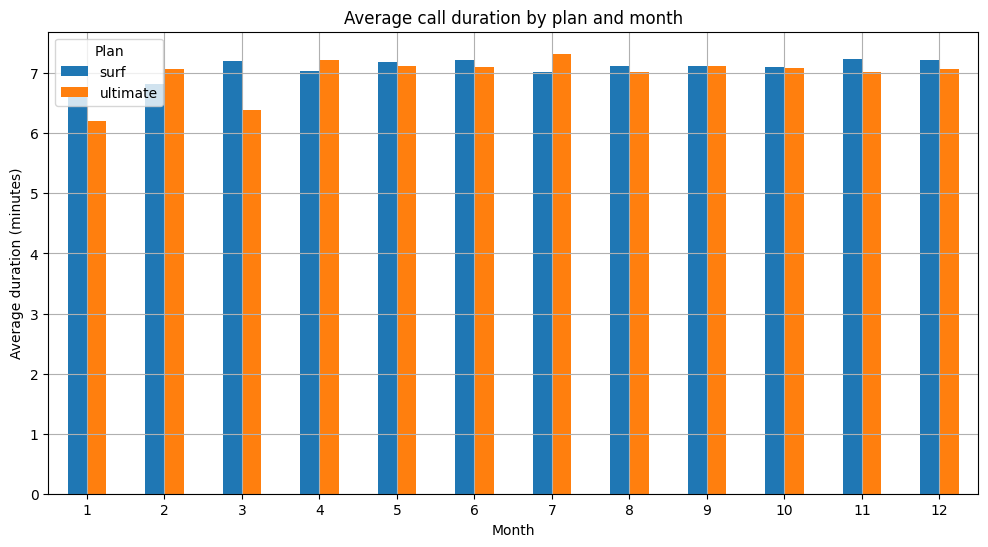

In [36]:
# Compare the average call duration by plan and month and plot a bar chart
mean_calls = calls_df.groupby(['user_id', 'month'])['duration'].mean().reset_index()
mean_calls_1 = mean_calls.merge(users_df[['user_id', 'plan']])

pivot_data = mean_calls_1.pivot_table(index='month', columns='plan', values='duration')

pivot_data.plot(kind='bar', figsize=(12, 6), grid=True)
plt.title('Average call duration by plan and month')
plt.xlabel('Month')
plt.ylabel('Average duration (minutes)')
plt.xticks(rotation=0)
plt.legend(title='Plan')
plt.show()

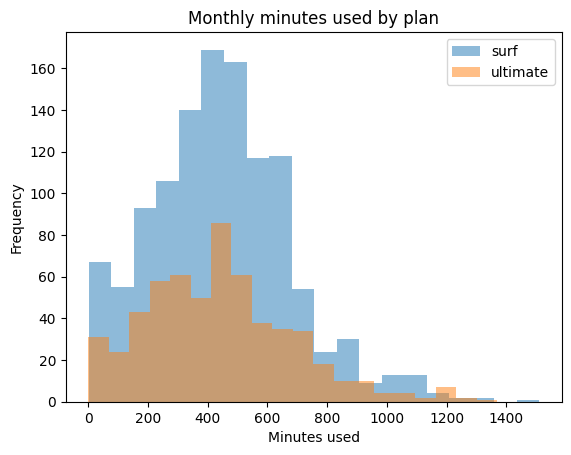

In [37]:
# Compare the monthly minutes used by each plan and plot a histogram
surf_users = user_info_monthly_3[user_info_monthly_3['plan'] == 'surf']
ultimate_users = user_info_monthly_3[user_info_monthly_3['plan'] == 'ultimate']

plt.hist(surf_users['minutes'], bins=20, alpha=0.5, label='surf')
plt.hist(ultimate_users['minutes'], bins=20, alpha=0.5, label='ultimate')
plt.title('Monthly minutes used by plan')
plt.xlabel('Minutes used')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [38]:
# Calculate the mean and variance of monthly call duration
monthly_call_stats = calls_df.groupby(['user_id', 'month'])['duration'].agg(['mean', 'var'])
monthly_call_stats = monthly_call_stats.rename(columns={'mean': 'mean_duration', 'var': 'variance_duration'})
print(monthly_call_stats)

               mean_duration  variance_duration
user_id month                                  
1000    12          7.750000          18.866667
1001    8           6.740741          22.584046
        9           6.428571          29.208333
        10          6.046154          28.825962
        11          6.656250          42.260913
...                      ...                ...
1498    12          8.692308          37.481781
1499    9           8.439024          33.202439
        10          7.264151          48.236575
        11          6.844444          29.088889
        12          7.630769          35.924038

[2258 rows x 2 columns]


C:\Users\Mauricio\AppData\Local\Temp\ipykernel_8\3648791129.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


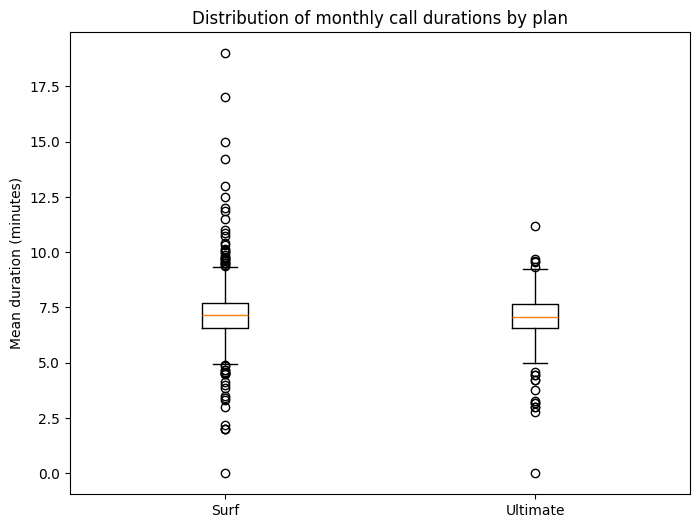

In [39]:
# Plot a boxplot to visualize the distribution of monthly call duration by plan
monthly_call_stats = monthly_call_stats.reset_index()
merged_data = pd.merge(monthly_call_stats, users_df[['user_id', 'plan']], on='user_id', how='left')

plt.figure(figsize=(8, 6))
plt.boxplot([
    merged_data[merged_data['plan'] == 'surf']['mean_duration'],
    merged_data[merged_data['plan'] == 'ultimate']['mean_duration']
], labels=['Surf', 'Ultimate'])
plt.title('Distribution of monthly call durations by plan')
plt.ylabel('Mean duration (minutes)')
plt.show()

Customer behavior differs between the two plans. Users on the Ultimate plan tend to make more calls, but their calls are typically shorter, while Surf users make fewer calls and keep them longer. This pattern suggests that the higher included allowance in the Ultimate plan encourages more frequent but shorter interactions.

### Messages

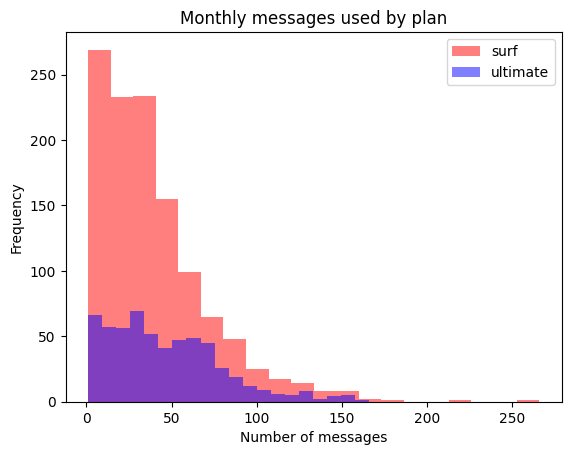

In [40]:
# Compare the number of messages sent each month by users on each plan
plt.hist(surf_users['number_messages'], bins=20, color='red', alpha=0.5, label='surf')
plt.hist(ultimate_users['number_messages'], bins=20, color='blue', alpha=0.5, label='ultimate')
plt.title('Monthly messages used by plan')
plt.xlabel('Number of messages')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [41]:
print(surf_users['number_messages'].describe())
print()
print(ultimate_users['number_messages'].describe())

count    1180.000000
mean       39.489831
std        32.314360
min         1.000000
25%        16.000000
50%        32.000000
75%        53.000000
max       266.000000
Name: number_messages, dtype: float64

count    579.000000
mean      46.455959
std       32.930135
min        1.000000
25%       21.000000
50%       41.000000
75%       66.000000
max      166.000000
Name: number_messages, dtype: float64


The histogram indicates a clear difference in messaging behavior between the two plans. Users on the Ultimate plan send more messages on average than Surf users, which is likely related to the larger monthly allowance included in their plan. Surf users appear to be more conservative in their usage, likely to avoid extra charges.

### Internet

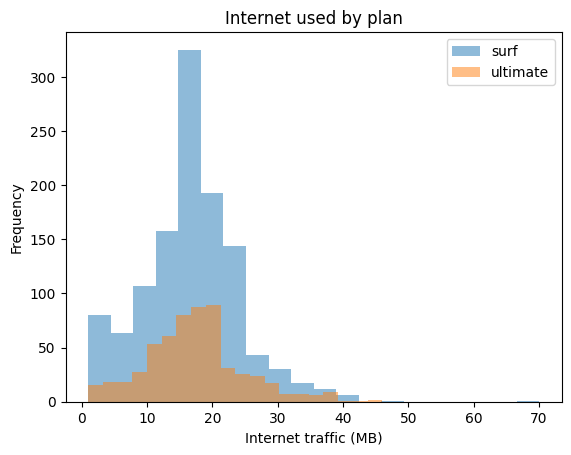

In [42]:
# Compare the amount of internet traffic consumed by users on each plan
plt.hist(surf_users['mb_used'], bins=20, alpha=0.5, label='surf')
plt.hist(ultimate_users['mb_used'], bins=20, alpha=0.5, label='ultimate')
plt.title('Internet used by plan')
plt.xlabel('Internet traffic (MB)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [43]:
surf_users['mb_used'].describe()

count    1180.000000
mean       16.752542
std         7.550662
min         1.000000
25%        13.000000
50%        17.000000
75%        21.000000
max        70.000000
Name: mb_used, dtype: float64

In [44]:
ultimate_users['mb_used'].describe()

count    579.000000
mean      17.343696
std        7.494935
min        1.000000
25%       13.000000
50%       17.000000
75%       21.000000
max       46.000000
Name: mb_used, dtype: float64

In summary, the chart and descriptive statistics suggest that Surf users tend to consume more internet data more frequently, despite their lower data allowance. Ultimate users, on the other hand, appear to use data less intensively overall.

## Revenue

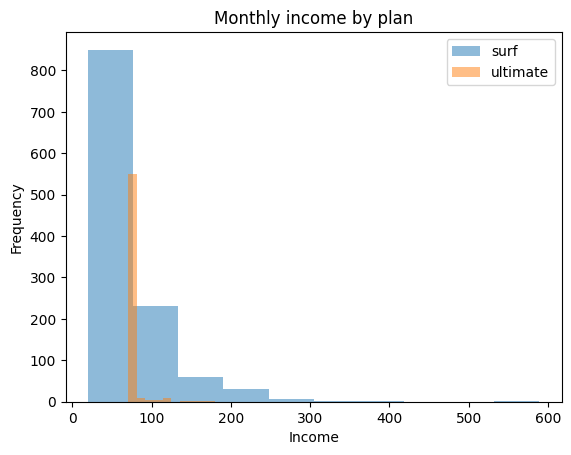

In [45]:
plt.hist(surf_users['monthly_income'], bins=10, alpha=0.5, label='surf')
plt.hist(ultimate_users['monthly_income'], alpha=0.5, bins=10, label='ultimate')
plt.title('Monthly income by plan')
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [46]:
surf_users['monthly_income'].describe()

count    1180.000000
mean       59.543309
std        53.159968
min        20.000000
25%        20.022500
50%        39.555710
75%        78.753210
max       588.890710
Name: monthly_income, dtype: float64

In [47]:
ultimate_users['monthly_income'].describe()

count    579.000000
mean      72.130668
std       10.639104
min       70.000000
25%       70.000000
50%       70.000000
75%       70.000000
max      179.928994
Name: monthly_income, dtype: float64

In summary, the plot and descriptive statistics suggest that Surf users are more likely to exceed their included allowance and generate additional charges. Ultimate users have a higher base monthly fee and tend to show more stable revenue patterns, with fewer users generating large excess charges.

## Test the statistical hypotheses

[Test the hypothesis that the average revenue from Ultimate users differs from that of Surf users.]

[Formulate the null and alternative hypotheses, choose an appropriate statistical test, and determine the significance level.]

In [48]:
# Hypothesis test for the difference in average revenue between Surf and Ultimate users
# H0: average monthly income is the same for both plans
# H1: average monthly income differs between the two plans

alpha = 0.05
results = st.ttest_ind(surf_users['monthly_income'], ultimate_users['monthly_income'])

print('p-value:', results.pvalue)

if results.pvalue < alpha:
    print('Reject the null hypothesis')
else:
    print('Fail to reject the null hypothesis')

p-value: 1.9597376215605627e-08
Reject the null hypothesis


[Test the hypothesis that the average revenue of users in the NY-NJ region differs from that of users in other regions.]

[Formulate the null and alternative hypotheses, choose an appropriate statistical test, and determine the significance level.]

In [49]:
# Merge the city information into the monthly user dataset
user_info_monthly_3 = pd.merge(user_info_monthly_3, users_df[['user_id', 'city']], on='user_id', how='left', suffixes=('_x', ''))
user_info_monthly_3.info()
print('---' * 15)
ny_nj_users = user_info_monthly_3[user_info_monthly_3['city'].str.contains('NY NJ')]
other_regions_users = user_info_monthly_3[~user_info_monthly_3['city'].str.contains('NY NJ')]

# Hypothesis test for the difference in average revenue between NY-NJ and other regions
# H0: average monthly income is the same for both regions
# H1: average monthly income differs between the two groups

alpha = 0.05
results = st.ttest_ind(ny_nj_users['monthly_income'], other_regions_users['monthly_income'])
print('p-value:', results.pvalue)

if results.pvalue < alpha:
    print('Reject the null hypothesis')
else:
    print('Fail to reject the null hypothesis')

<class 'pandas.DataFrame'>
RangeIndex: 1759 entries, 0 to 1758
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   user_id          1759 non-null   int64  
 1   month            1759 non-null   int32  
 2   number_of_calls  1759 non-null   int64  
 3   minutes          1759 non-null   float64
 4   number_messages  1759 non-null   int64  
 5   mb_used          1759 non-null   float64
 6   plan             1759 non-null   str    
 7   monthly_income   1759 non-null   float64
 8   city             1759 non-null   str    
dtypes: float64(3), int32(1), int64(3), str(2)
memory usage: 116.9 KB
---------------------------------------------
p-value: 0.00840447567509002
Reject the null hypothesis


## General conclusion

This analysis compared the Surf and Ultimate prepaid plans at Megaline to determine which plan generates more revenue and how customer behavior differs between the two groups. After preparing and combining the data, I examined usage patterns for calls, messages, internet traffic, and monthly income using the plan rules and overage pricing.

The results suggest that Ultimate users tend to consume more services overall, including more calls, messages, and internet traffic, which is associated with higher average monthly revenue per user. Surf users use fewer services on average, but they still generate revenue through overage charges. Based on this sample, Ultimate appears to be the more profitable plan.

The statistical analysis supports this conclusion. A two-sample independent t-test was used with a significance level of $\alpha = 0.05$. The first hypothesis test compared the average revenue of Surf and Ultimate users and led to rejection of the null hypothesis, indicating a statistically significant difference between the two plans. The second hypothesis test compared users in the NY-NJ region with users in other regions and also rejected the null hypothesis, suggesting that regional differences are also associated with differences in revenue.

Overall, the evidence indicates that Ultimate is the stronger revenue-generating plan in this dataset, while regional differences may also influence customer spending patterns and should be explored further in future analysis.